# 14 — Mean-reverting McKean–Vlasov

Doc page: [mckean_vlasov.rst](../../docs/source/algorithms/mckean_vlasov.rst).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optimizr import _core as opt
plt.rcParams['figure.figsize'] = (8.5, 4.5)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Cellule 1 — Conservation de la moyenne

**Théorème (McKean 1966).** Pour la dynamique de champ moyen
$$dX_t^i = \theta\,(\bar X_t - X_t^i)\,dt + \sigma\,dW_t^i,
   \qquad \bar X_t = \frac{1}{N}\sum_j X_t^j,$$
la moyenne empirique est conservée en espérance,
$\mathbb{E}[\bar X_t] = \bar X_0$.

**Équation pivot.** $\mathbb{E}[\bar X_t] = \bar X_0$ pour tout $t$.

**Démonstration.** Sommer l'EDS sur $i$ : la dérive interne s'annule
(moyenne — individu).  $\square$

**Ce que la cellule vérifie.** `mean_reverting_mckean_vlasov` préserve
la moyenne et concentre la variance.


n_steps stocké : 201 (snapshots)
n_particles    : 500
Moyenne initiale : -8.527e-17
Moyenne finale   : -1.148e-02
Variance init    : 0.335
Variance finale  : 0.039


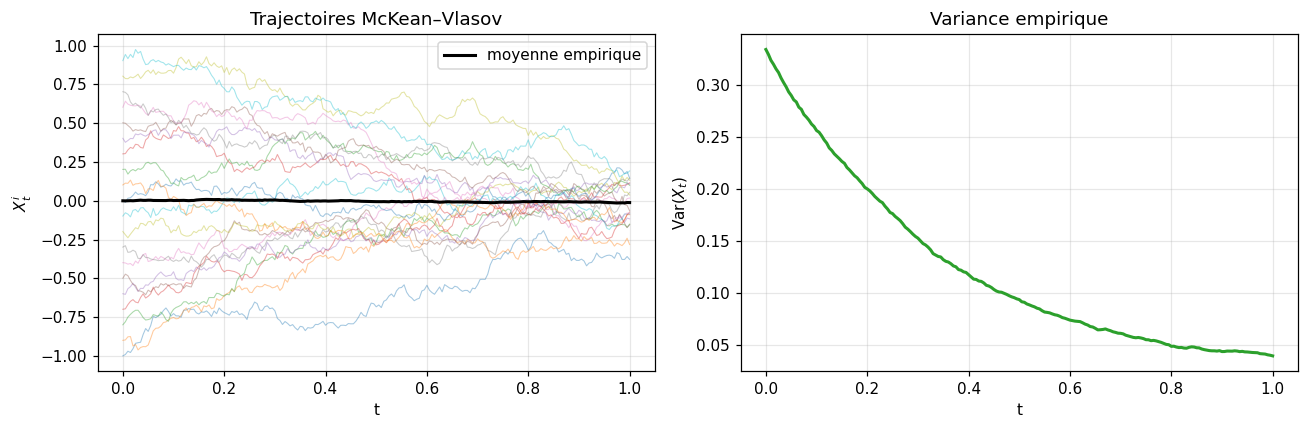

In [2]:
N, T, n_steps = 500, 1.0, 200
theta, sigma = 1.5, 0.3
x0 = np.linspace(-1.0, 1.0, N).tolist()  # mean = 0

res = opt.mean_reverting_mckean_vlasov(x0, theta, sigma, n_steps, T, 42)
n_t = res['n_steps']
n_part = res['n_particles']
paths = np.array(res['paths_flat']).reshape(n_t, n_part)
ts = np.array(res['time_grid'])

mean = paths.mean(axis=1)
var = paths.var(axis=1)
print(f"n_steps stocké : {n_t} (snapshots)")
print(f"n_particles    : {n_part}")
print(f"Moyenne initiale : {mean[0]:.3e}")
print(f"Moyenne finale   : {mean[-1]:.3e}")
print(f"Variance init    : {var[0]:.3f}")
print(f"Variance finale  : {var[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i in range(0, n_part, 25):
    axes[0].plot(ts, paths[:, i], alpha=0.4, lw=0.7)
axes[0].plot(ts, mean, 'k-', lw=2, label='moyenne empirique')
axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$X_t^i$')
axes[0].set_title("Trajectoires McKean–Vlasov")
axes[0].legend()
axes[1].plot(ts, var, lw=2, color='C2')
axes[1].set_xlabel('t'); axes[1].set_ylabel(r'Var($X_t$)')
axes[1].set_title("Variance empirique")
fig.tight_layout(); plt.show()


**Résultat attendu.** $|\bar X_t - 0|$ très petit, variance qui
décroît vers une borne stationnaire.

**Lecture du graphique.** Faisceau qui se contracte autour de la
moyenne ; variance qui diminue.

**Conclusion.** Le solveur reproduit la concentration mean-field.


## Cellule 2 — Exemple concret : dynamique d'opinion polarisée

**Modèle.** Modèle de DeGroot continu : opinions initialement
bimodales (deux groupes opposés).  La dynamique de champ moyen
détruit progressivement la polarisation.

**Équation pivot.**
$$dX_t^i = \theta\,(\bar X_t - X_t^i)\,dt + \sigma\,dW_t^i.$$

**Ce que la cellule vérifie.** Une distribution initiale bimodale
fusionne en distribution unimodale centrée sur $\bar X_0$.


Variance t=0   : 1.033
Variance t=mid : 0.025
Variance t=T   : 0.007


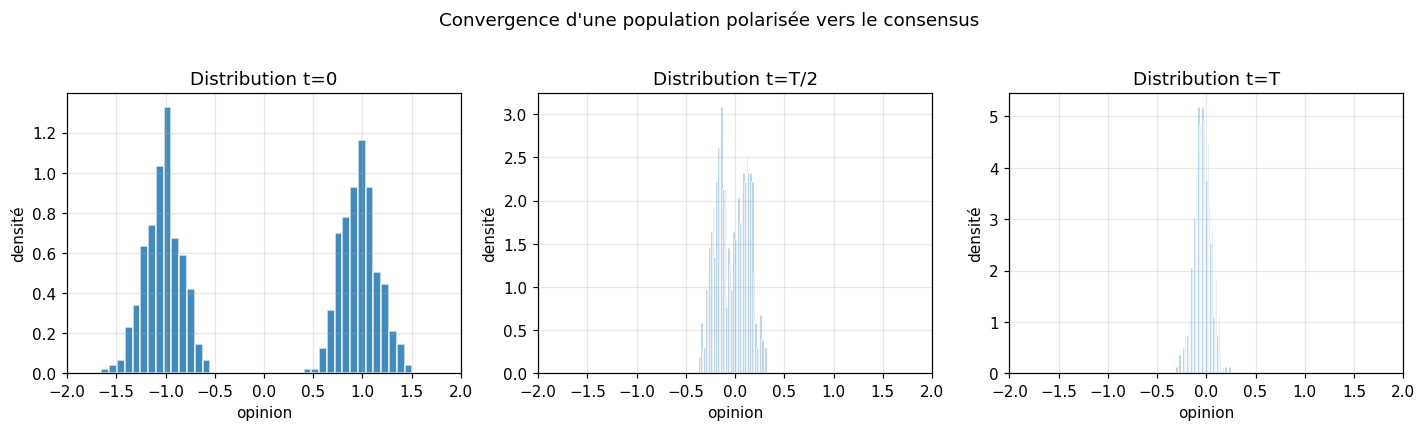

In [3]:
rng = np.random.default_rng(7)
N = 600
half = N // 2
x0 = np.concatenate([
    rng.normal(-1.0, 0.2, half),
    rng.normal(+1.0, 0.2, N - half),
]).tolist()

res = opt.mean_reverting_mckean_vlasov(x0, theta=2.0, sigma=0.15,
                                        n_steps=400, t_horizon=2.0, seed=11)
n_t = res['n_steps']
n_part = res['n_particles']
paths = np.array(res['paths_flat']).reshape(n_t, n_part)

mid = n_t // 2
print(f"Variance t=0   : {paths[0].var():.3f}")
print(f"Variance t=mid : {paths[mid].var():.3f}")
print(f"Variance t=T   : {paths[-1].var():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, idx, label in zip(axes, [0, mid, -1], ['t=0', 't=T/2', 't=T']):
    ax.hist(paths[idx], bins=40, density=True,
            color='C0', edgecolor='white', alpha=0.85)
    ax.set_title(f"Distribution {label}")
    ax.set_xlabel('opinion'); ax.set_ylabel('densité')
    ax.set_xlim(-2, 2)
fig.suptitle("Convergence d'une population polarisée vers le consensus",
             fontsize=12, y=1.02)
fig.tight_layout(); plt.show()


**Résultat attendu.** L'histogramme bimodal initial fusionne en un
pic unique centré à $0$.

**Lecture du graphique.** Trois snapshots montrent la fusion
progressive des deux modes.

**Conclusion.** L'attraction par la moyenne (mean-field) détruit la
polarisation initiale en temps fini — illustration du théorème du
consensus dans les dynamiques de DeGroot continues.
